<a href="https://colab.research.google.com/github/chirontan/FEM/blob/main/Q3_(d).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Solution to Q.3(d)**

Galerkin coefficients:
c1 = 0.2537313432835819
c2 = -0.08955223880597002

Petrov-Galerkin coefficients:
c1 = 0.2666666666666665
c2 = -0.09999999999999988

L2 errors:
Galerkin       = 0.005757342045811096
Petrov-Galerkin = 0.008459522041167173


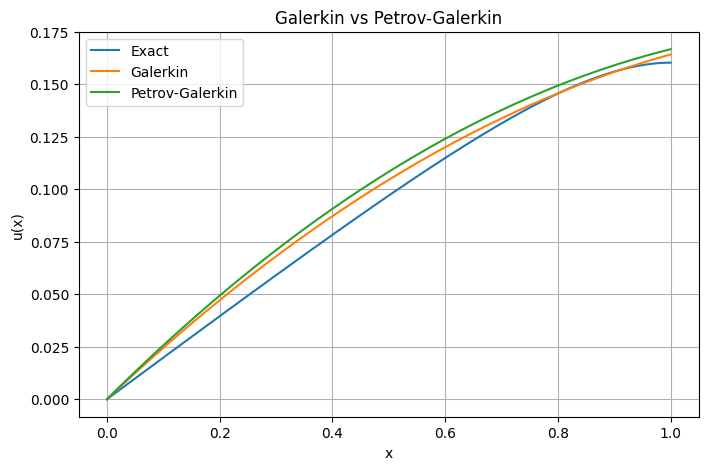

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ---------------------------------------------------------
# Exact solution
# ---------------------------------------------------------
beta = 5.0

def u_exact(x):
    return (
        x/beta
        - (np.exp(beta*(x-1)) - np.exp(-beta))/beta**2
    )


# ---------------------------------------------------------
# Galerkin matrix and RHS
# ---------------------------------------------------------
K_G = np.array([
    [7/2, 13/3],
    [8/3, 23/6]
])

F_G = np.array([
    1/2,
    1/3
])

c_G = np.linalg.solve(K_G, F_G)


# ---------------------------------------------------------
# Petrov-Galerkin matrix and RHS
# ---------------------------------------------------------
K_PG = np.array([
    [7/2, 13/3],
    [9/4, 7/2]
])

F_PG = np.array([
    1/2,
    1/4
])

c_PG = np.linalg.solve(K_PG, F_PG)


# ---------------------------------------------------------
# Approximate solutions
# ---------------------------------------------------------
def u_G(x):
    return c_G[0]*x + c_G[1]*x**2


def u_PG(x):
    return c_PG[0]*x + c_PG[1]*x**2


# ---------------------------------------------------------
# L2 errors
# ---------------------------------------------------------
error_G = np.sqrt(
    quad(lambda x: (u_exact(x) - u_G(x))**2, 0, 1)[0]
)

error_PG = np.sqrt(
    quad(lambda x: (u_exact(x) - u_PG(x))**2, 0, 1)[0]
)


# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------
print("Galerkin coefficients:")
print("c1 =", c_G[0])
print("c2 =", c_G[1])

print("\nPetrov-Galerkin coefficients:")
print("c1 =", c_PG[0])
print("c2 =", c_PG[1])

print("\nL2 errors:")
print("Galerkin       =", error_G)
print("Petrov-Galerkin =", error_PG)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
x = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))

plt.plot(x, u_exact(x), label="Exact")
plt.plot(x, u_G(x), label="Galerkin")
plt.plot(x, u_PG(x), label="Petrov-Galerkin")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Galerkin vs Petrov-Galerkin")
plt.legend()
plt.grid(True)
plt.show()